In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

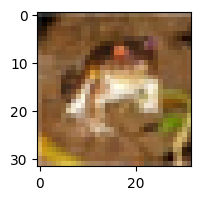

In [6]:
plt.figure(figsize=(15, 2))
plt.imshow(X_train[0])

In [7]:
y_train.shape

(50000, 1)

In [8]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [9]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [10]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [11]:
classes[9]

'truck'

In [12]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

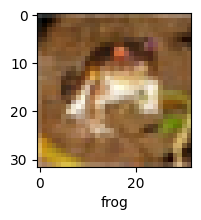

In [13]:
plot_sample(X_train, y_train, 0)

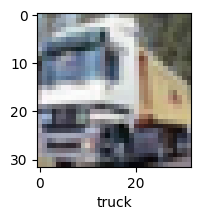

In [14]:
plot_sample(X_train, y_train, 1)

In [15]:
X_train = X_train /255
X_test = X_test / 255

In [16]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

ann.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=5)

d:\Work\On\.PRACTISE\Learn\deep-learning-with-Tensorflow\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3559 - loss: 1.8096
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.4258 - loss: 1.6236
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.4573 - loss: 1.5413
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.4786 - loss: 1.4829
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.4968 - loss: 1.4341


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification_report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Classification_report: 
               precision    recall  f1-score   support

           0       0.65      0.45      0.54      1000
           1       0.68      0.50      0.58      1000
           2       0.33      0.45      0.38      1000
           3       0.39      0.28      0.32      1000
           4       0.36      0.46      0.40      1000
           5       0.42      0.36      0.39      1000
           6       0.46      0.61      0.53      1000
           7       0.55      0.56      0.55      1000
           8       0.72      0.53      0.61      1000
           9       0.52      0.65      0.57      1000

    accuracy                           0.49     10000
   macro avg       0.51      0.49      0.49     10000
weighted avg       0.51      0.49      0.49     10000



In [18]:
# 1: 0.45
# 2: 0.67

# 1: (0.45) / (0.45+0.67)

(0.45) / (0.45+0.67)

0.40178571428571425

In [19]:
(0.67) / (0.45+0.67)

0.5982142857142857

In [20]:
cnn = models.Sequential([
    
    #cnn
    layers.Conv2D(filters=32, activation='relu', kernel_size=(3,3), input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    #dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


d:\Work\On\.PRACTISE\Learn\deep-learning-with-Tensorflow\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
cnn.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.4909 - loss: 1.4303
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6260 - loss: 1.0751
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.6704 - loss: 0.9499
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6999 - loss: 0.8624
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7266 - loss: 0.7891
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.7476 - loss: 0.7304
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7661 - loss: 0.6756
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7826 - loss: 0.6272
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7960 - loss: 0.5883
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8104 - loss: 0.5420


In [23]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7121 - loss: 0.9112


[0.911216676235199, 0.7121000289916992]

In [24]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

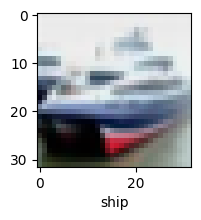

In [25]:
y_test = y_test.reshape(-1,)
plot_sample(X_test, y_test, 1)

In [26]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.41284530e-04, 3.45800479e-04, 5.56992600e-04, 8.35389316e-01,
        2.38083676e-03, 7.07862526e-02, 6.26645014e-02, 2.76574225e-04,
        2.72974521e-02, 1.60951182e-04],
       [4.19139251e-04, 1.46569812e-03, 2.66003468e-07, 3.58681547e-07,
        3.11705634e-10, 1.36312215e-08, 2.08344542e-09, 8.32936498e-11,
        9.98113275e-01, 1.20982077e-06],
       [3.09111960e-02, 3.90609750e-03, 2.43151353e-05, 5.94487705e-04,
        1.16296287e-03, 1.00679106e-04, 5.54264298e-05, 1.47980405e-04,
        9.57566023e-01, 5.53073455e-03],
       [9.02366102e-01, 1.76977657e-03, 3.30910198e-02, 4.22328850e-03,
        1.68579747e-03, 4.95760833e-05, 1.03779508e-04, 1.26341271e-04,
        5.64404540e-02, 1.43746511e-04],
       [1.16812533e-08, 2.61199045e-08, 9.52731789e-05, 4.92589222e-03,
        9.13233340e-01, 1.33521280e-05, 8.17318633e-02, 2.01678603e-07,
        5.71129526e-08, 1.49727508e-09]], dtype=float32)

In [27]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [28]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

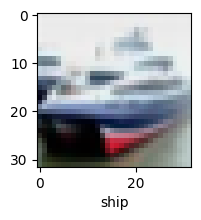

In [29]:
plot_sample(X_test, y_test, 1)

In [ ]:
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [31]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[1.41284530e-04, 3.45800479e-04, 5.56992600e-04, 8.35389316e-01,
        2.38083676e-03, 7.07862526e-02, 6.26645014e-02, 2.76574225e-04,
        2.72974521e-02, 1.60951182e-04],
       [4.19139251e-04, 1.46569812e-03, 2.66003468e-07, 3.58681547e-07,
        3.11705634e-10, 1.36312215e-08, 2.08344542e-09, 8.32936498e-11,
        9.98113275e-01, 1.20982077e-06],
       [3.09111960e-02, 3.90609750e-03, 2.43151353e-05, 5.94487705e-04,
        1.16296287e-03, 1.00679106e-04, 5.54264298e-05, 1.47980405e-04,
        9.57566023e-01, 5.53073455e-03],
       [9.02366102e-01, 1.76977657e-03, 3.30910198e-02, 4.22328850e-03,
        1.68579747e-03, 4.95760833e-05, 1.03779508e-04, 1.26341271e-04,
        5.64404540e-02, 1.43746511e-04],
       [1.16812533e-08, 2.61199045e-08, 9.52731789e-05, 4.92589222e-03,
        9.13233340e-01, 1.33521280e-05, 8.17318633e-02, 2.01678603e-07,
        5.71129526e-08, 1.49727508e-09]], dtype=float32)

In [32]:
np.argmax([5,12,1,2])

np.int64(1)

In [33]:
np.argmax(y_pred[0])

np.int64(3)

In [35]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [36]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

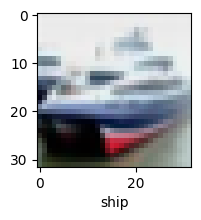

In [37]:
plot_sample(X_test, y_test, 1)

In [38]:
classes[y_classes[1]]

'ship'

In [39]:
print("classification_report: \n", classification_report(y_test, y_classes))

classification_report: 
               precision    recall  f1-score   support

           0       0.76      0.77      0.76      1000
           1       0.86      0.78      0.82      1000
           2       0.70      0.51      0.59      1000
           3       0.48      0.59      0.53      1000
           4       0.60      0.75      0.67      1000
           5       0.64      0.56      0.60      1000
           6       0.79      0.75      0.77      1000
           7       0.77      0.78      0.78      1000
           8       0.82      0.82      0.82      1000
           9       0.79      0.81      0.80      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000

